# 残差の確認

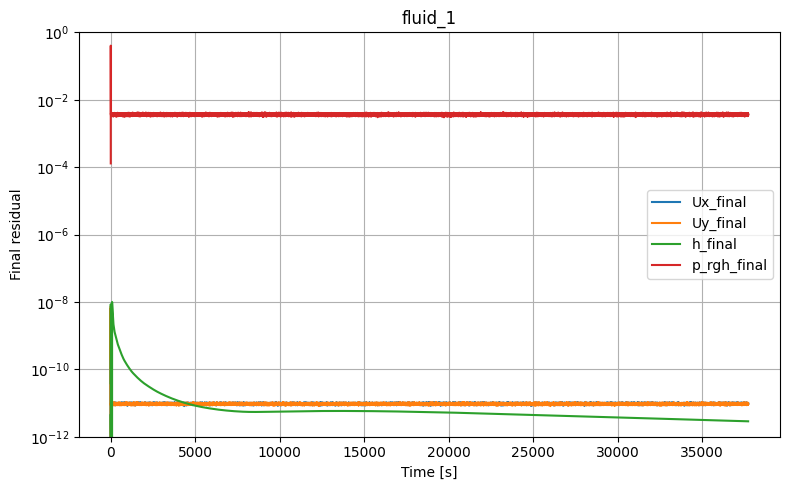

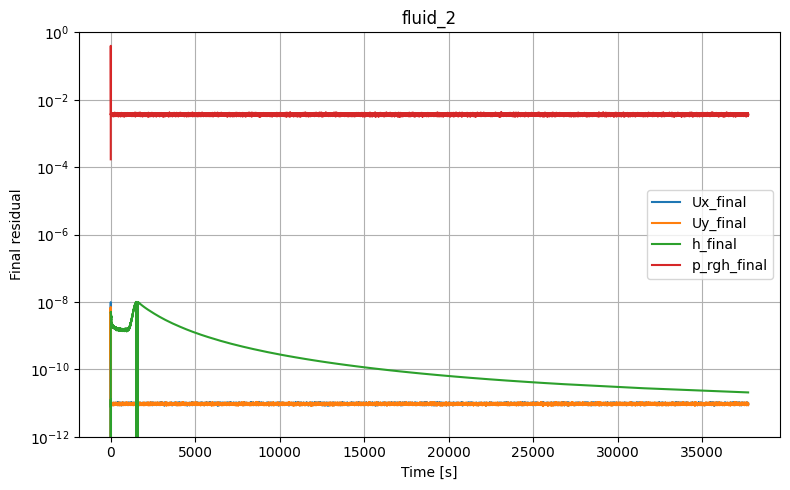

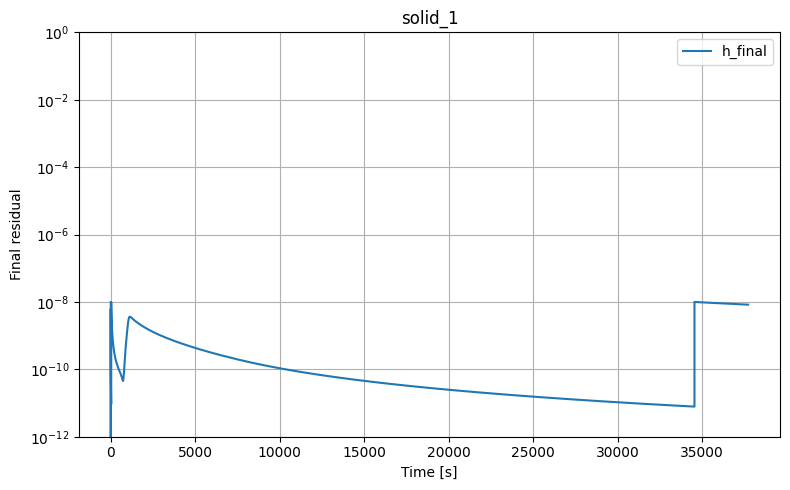

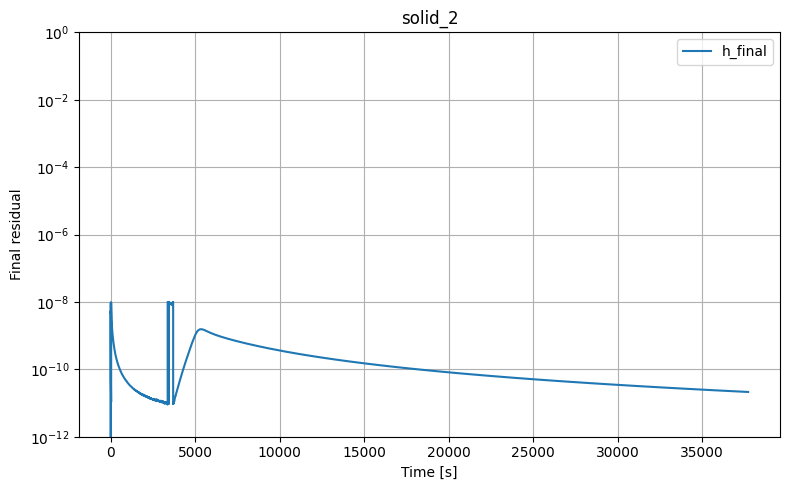

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_fluid_residual(file_path, label, ymin=1e-12, ymax=1):
    df = pd.read_csv(
        file_path,
        comment="#",
        sep=r"\s+",
        header=None,
        names=[
            "Time",
            "U_solver",
            "Ux_initial",
            "Ux_final",
            "Ux_iters",
            "Uy_initial",
            "Uy_final",
            "Uy_iters",
            "U_converged",
            "h_solver",
            "h_initial",
            "h_final",
            "h_iters",
            "h_converged",
            "p_rgh_solver",
            "p_rgh_initial",
            "p_rgh_final",
            "p_rgh_iters",
            "p_rgh_converged",
        ],
        engine="python"
    )

    plt.figure(figsize=(8, 5))
    plt.plot(df["Time"], df["Ux_final"], label="Ux_final")
    plt.plot(df["Time"], df["Uy_final"], label="Uy_final")
    plt.plot(df["Time"], df["h_final"], label="h_final")
    plt.plot(df["Time"], df["p_rgh_final"], label="p_rgh_final")

    plt.yscale("log")
    plt.ylim(ymin, ymax)
    plt.xlabel("Time [s]")
    plt.ylabel("Final residual")
    plt.title(label)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_solid_residual(file_path, label, ymin=1e-12, ymax=1):
    df = pd.read_csv(
        file_path,
        comment="#",
        sep=r"\s+",
        header=None,
        names=[
            "Time",
            "h_solver",
            "h_initial",
            "h_final",
            "h_iters",
            "h_converged",
        ],
        engine="python"
    )

    plt.figure(figsize=(8, 5))
    plt.plot(df["Time"], df["h_final"], label="h_final")

    plt.yscale("log")
    plt.ylim(ymin, ymax)
    plt.xlabel("Time [s]")
    plt.ylabel("Final residual")
    plt.title(label)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_fluid_residual(
    "postProcessing/fluid_1/residuals_fluid_1/0/solverInfo.dat",
    "fluid_1"
)

plot_fluid_residual(
    "postProcessing/fluid_2/residuals_fluid_2/0/solverInfo.dat",
    "fluid_2"
)

plot_solid_residual(
    "postProcessing/solid_1/residuals_solid_1/0/solverInfo.dat",
    "solid_1"
)

plot_solid_residual(
    "postProcessing/solid_2/residuals_solid_2/0/solverInfo.dat",
    "solid_2"
)

# 熱量の比較

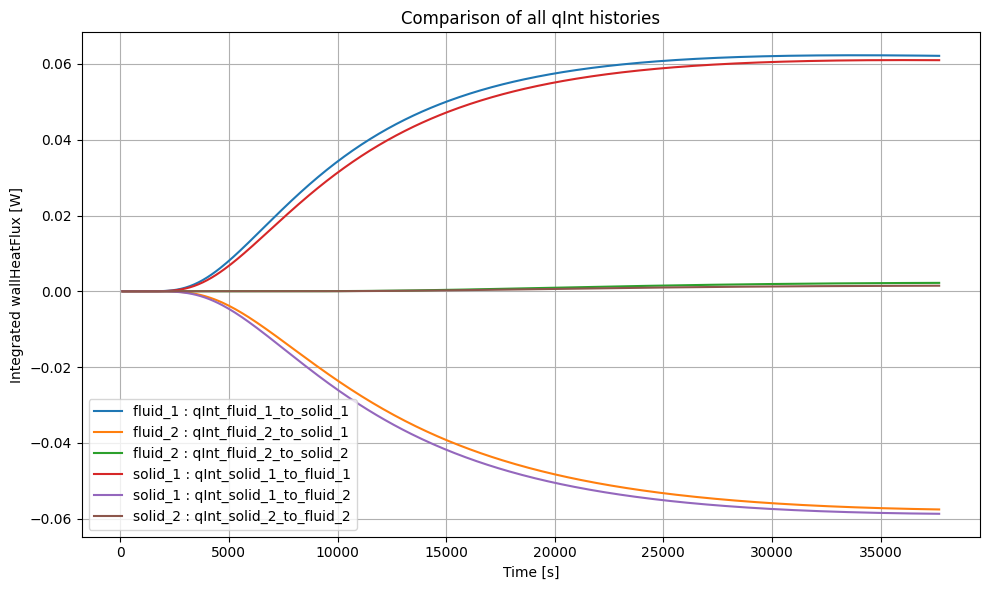

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path

# ====================================
# qInt_* のファイルを全部取得
# ====================================
files = sorted(glob("postProcessing/*/qInt_*/0/surfaceFieldValue.dat"))

if not files:
    raise FileNotFoundError("qInt_* の surfaceFieldValue.dat が見つかりません")

# ====================================
# 読み込み関数
# ====================================
def read_surface_field_value(filepath):
    return pd.read_csv(
        filepath,
        comment="#",
        sep=r"\s+",
        header=None,
        names=["Time", "Value"],
        engine="python"
    )

# ====================================
# ラベル作成
# ====================================
def make_label(filepath):
    p = Path(filepath)
    region = p.parts[1]
    name = p.parts[2]
    return f"{region} : {name}"

# ====================================
# 全 qInt を1枚に重ね描き
# fluid 側は符号反転
# ====================================
plt.figure(figsize=(10, 6))

for f in files:
    df = read_surface_field_value(f)
    label = make_label(f)

    path_str = str(f).replace("\\", "/")
    if "/fluid_" in path_str:
        y = -df["Value"]
    else:
        y = df["Value"]

    plt.plot(df["Time"], y, label=label)

plt.xlabel("Time [s]")
plt.ylabel("Integrated wallHeatFlux [W]")
plt.title("Comparison of all qInt histories")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

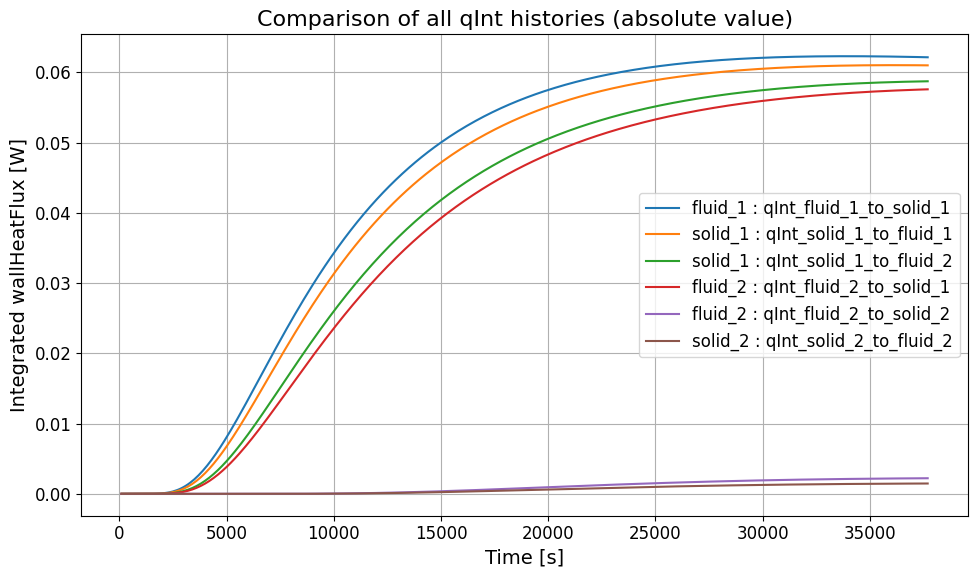

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# フォントサイズを統一
plt.rcParams["font.size"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

# 表示したい順番で定義
targets = [
    ("fluid_1 : qInt_fluid_1_to_solid_1",
     "postProcessing/fluid_1/qInt_fluid_1_to_solid_1/0/surfaceFieldValue.dat"),

    ("solid_1 : qInt_solid_1_to_fluid_1",
     "postProcessing/solid_1/qInt_solid_1_to_fluid_1/0/surfaceFieldValue.dat"),

    ("solid_1 : qInt_solid_1_to_fluid_2",
     "postProcessing/solid_1/qInt_solid_1_to_fluid_2/0/surfaceFieldValue.dat"),

    ("fluid_2 : qInt_fluid_2_to_solid_1",
     "postProcessing/fluid_2/qInt_fluid_2_to_solid_1/0/surfaceFieldValue.dat"),

    ("fluid_2 : qInt_fluid_2_to_solid_2",
     "postProcessing/fluid_2/qInt_fluid_2_to_solid_2/0/surfaceFieldValue.dat"),

    ("solid_2 : qInt_solid_2_to_fluid_2",
     "postProcessing/solid_2/qInt_solid_2_to_fluid_2/0/surfaceFieldValue.dat"),
]

def read_surface_field_value(filepath):
    return pd.read_csv(
        filepath,
        comment="#",
        sep=r"\s+",
        header=None,
        names=["Time", "Value"],
        engine="python"
    )

plt.figure(figsize=(10, 6))

for label, filepath in targets:
    df = read_surface_field_value(filepath)

    # 全部正の値で表示
    y = df["Value"].abs()

    plt.plot(df["Time"], y, label=label)

plt.xlabel("Time [s]")
plt.ylabel("Integrated wallHeatFlux [W]")
plt.title("Comparison of all qInt histories (absolute value)")
plt.grid(True)
plt.legend()
plt.tight_layout()

# 画像保存
plt.savefig("qInt_all_histories.png", dpi=300, bbox_inches="tight")

plt.show()

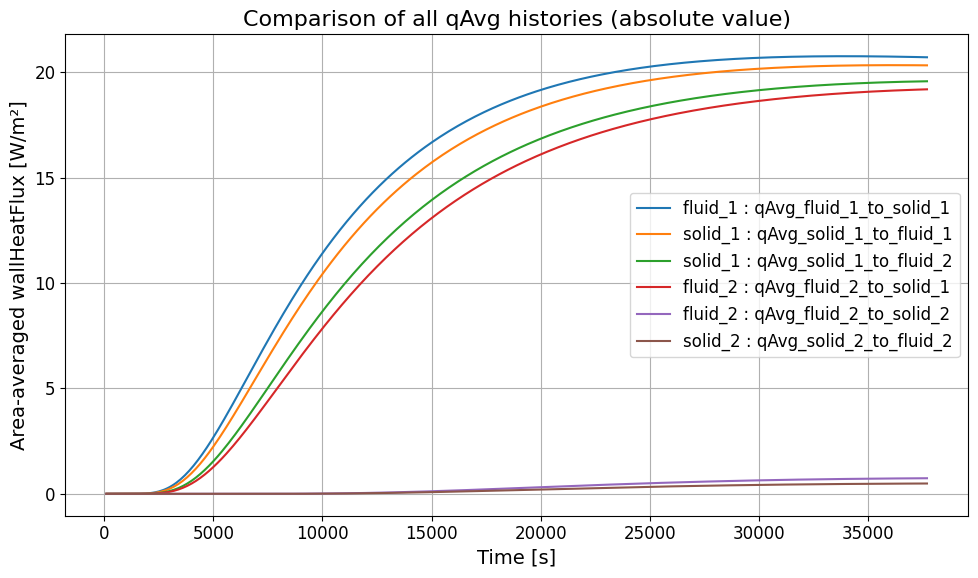

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# フォントサイズを統一
plt.rcParams["font.size"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

# 表示したい順番（qAvg版）
targets = [
    ("fluid_1 : qAvg_fluid_1_to_solid_1",
     "postProcessing/fluid_1/qAvg_fluid_1_to_solid_1/0/surfaceFieldValue.dat"),

    ("solid_1 : qAvg_solid_1_to_fluid_1",
     "postProcessing/solid_1/qAvg_solid_1_to_fluid_1/0/surfaceFieldValue.dat"),

    ("solid_1 : qAvg_solid_1_to_fluid_2",
     "postProcessing/solid_1/qAvg_solid_1_to_fluid_2/0/surfaceFieldValue.dat"),

    ("fluid_2 : qAvg_fluid_2_to_solid_1",
     "postProcessing/fluid_2/qAvg_fluid_2_to_solid_1/0/surfaceFieldValue.dat"),

    ("fluid_2 : qAvg_fluid_2_to_solid_2",
     "postProcessing/fluid_2/qAvg_fluid_2_to_solid_2/0/surfaceFieldValue.dat"),

    ("solid_2 : qAvg_solid_2_to_fluid_2",
     "postProcessing/solid_2/qAvg_solid_2_to_fluid_2/0/surfaceFieldValue.dat"),
]

def read_surface_field_value(filepath):
    return pd.read_csv(
        filepath,
        comment="#",
        sep=r"\s+",
        header=None,
        names=["Time", "Value"],
        engine="python"
    )

plt.figure(figsize=(10, 6))

for label, filepath in targets:
    df = read_surface_field_value(filepath)

    # 正の値で比較
    y = df["Value"].abs()

    plt.plot(df["Time"], y, label=label)

plt.xlabel("Time [s]")
plt.ylabel("Area-averaged wallHeatFlux [W/m²]")
plt.title("Comparison of all qAvg histories (absolute value)")
plt.grid(True)
plt.legend()
plt.tight_layout()

# 保存
plt.savefig("qAvg_all_histories.png", dpi=300, bbox_inches="tight")

plt.show()

# 計算方法を変えて

C:\Users\user\AppData\Local\Temp\ipykernel_13852\1125999713.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


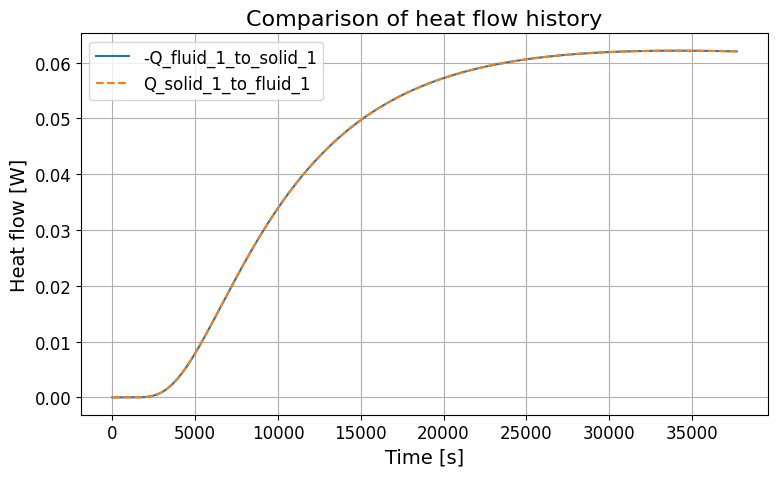

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ファイル名
file_path = "postProcessing/interfaceHeatFlow/interfaceHeatFlow.dat"

# 読み込み
df = pd.read_csv(
    file_path,
    comment="#",
    delim_whitespace=True,
    header=None,
    names=[
        "time",
        "Q_fluid_1_to_solid_1",
        "Q_solid_1_to_fluid_1",
        "balance",
        "qAvg_fluid_1_to_solid_1",
        "qAvg_solid_1_to_fluid_1",
        "area"
    ]
)

# Q_fluid_1_to_solid_1 を負にする
df["minus_Q_fluid_1_to_solid_1"] = -df["Q_fluid_1_to_solid_1"]

# プロット
plt.figure(figsize=(8, 5))
plt.plot(df["time"], -df["minus_Q_fluid_1_to_solid_1"], label="-Q_fluid_1_to_solid_1")
plt.plot(df["time"], -df["Q_solid_1_to_fluid_1"], label="Q_solid_1_to_fluid_1", linestyle="--")

plt.xlabel("Time [s]")
plt.ylabel("Heat flow [W]")
plt.title("Comparison of heat flow history")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

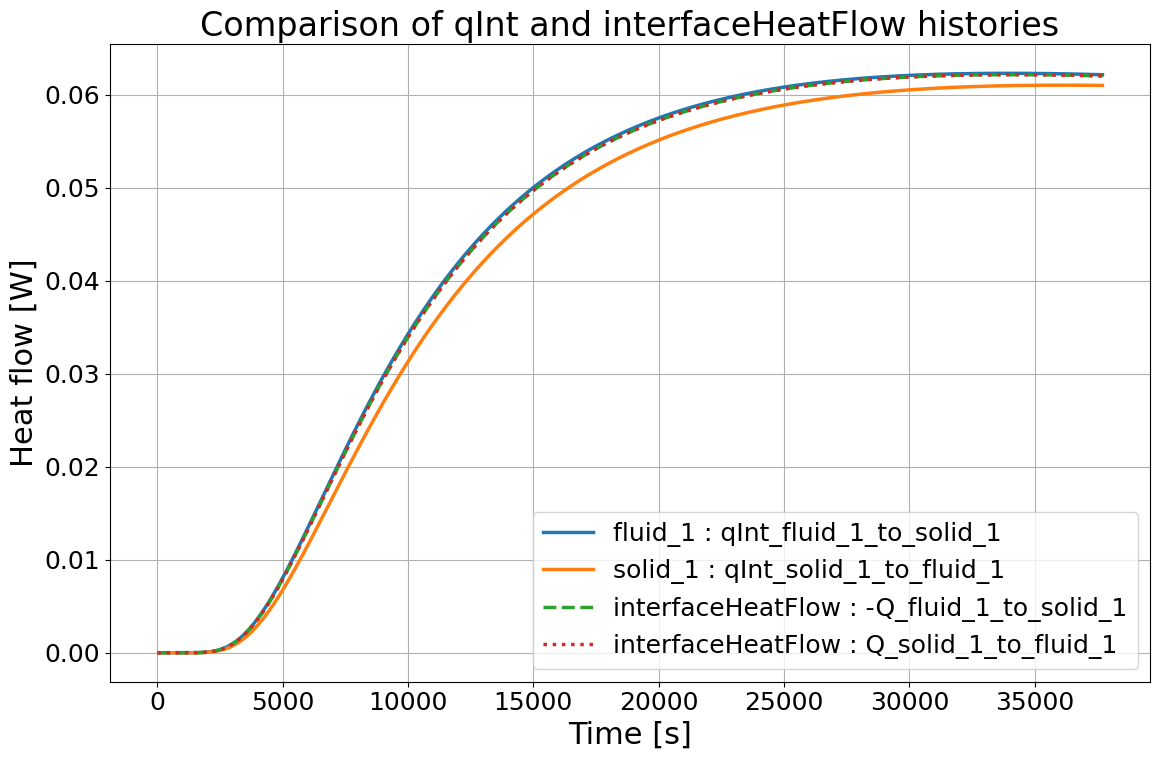

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 保存先フォルダ
# -----------------------------
output_dir = Path("pdf")
output_dir.mkdir(exist_ok=True)

# -----------------------------
# フォントサイズを大きめに設定
# -----------------------------
plt.rcParams["font.size"] = 20
plt.rcParams["axes.titlesize"] = 24
plt.rcParams["axes.labelsize"] = 22
plt.rcParams["legend.fontsize"] = 18
plt.rcParams["xtick.labelsize"] = 18
plt.rcParams["ytick.labelsize"] = 18

# qInt の対象
targets = [
    ("fluid_1 : qInt_fluid_1_to_solid_1",
     "postProcessing/fluid_1/qInt_fluid_1_to_solid_1/0/surfaceFieldValue.dat"),

    ("solid_1 : qInt_solid_1_to_fluid_1",
     "postProcessing/solid_1/qInt_solid_1_to_fluid_1/0/surfaceFieldValue.dat"),
]

def read_surface_field_value(filepath):
    path = Path(filepath)
    if not path.exists():
        print(f"[WARNING] File not found: {filepath}")
        return None

    return pd.read_csv(
        filepath,
        comment="#",
        sep=r"\s+",
        header=None,
        names=["Time", "Value"],
        engine="python"
    )

# interfaceHeatFlow.dat 読み込み
interface_file = "postProcessing/interfaceHeatFlow/interfaceHeatFlow.dat"
interface_path = Path(interface_file)

plt.figure(figsize=(12, 8))

# qInt を重ね描き
for label, filepath in targets:
    df_qint = read_surface_field_value(filepath)
    if df_qint is None:
        continue

    plt.plot(
        df_qint["Time"],
        df_qint["Value"].abs(),
        label=label,
        linewidth=2.5
    )

# interfaceHeatFlow も同じグラフに追加
if interface_path.exists():
    df_interface = pd.read_csv(
        interface_file,
        comment="#",
        sep=r"\s+",
        header=None,
        names=[
            "time",
            "Q_fluid_1_to_solid_1",
            "Q_solid_1_to_fluid_1",
            "balance",
            "qAvg_fluid_1_to_solid_1",
            "qAvg_solid_1_to_fluid_1",
            "area"
        ],
        engine="python"
    )

    plt.plot(
        df_interface["time"],
        (-df_interface["Q_fluid_1_to_solid_1"]).abs(),
        label="interfaceHeatFlow : -Q_fluid_1_to_solid_1",
        linestyle="--",
        linewidth=2.5
    )

    plt.plot(
        df_interface["time"],
        df_interface["Q_solid_1_to_fluid_1"].abs(),
        label="interfaceHeatFlow : Q_solid_1_to_fluid_1",
        linestyle=":",
        linewidth=2.5
    )

plt.xlabel("Time [s]")
plt.ylabel("Heat flow [W]")
plt.title("Comparison of qInt and interfaceHeatFlow histories")
plt.grid(True)
plt.legend()
plt.tight_layout()

# PNG保存
plt.savefig("all_heatflow_histories_one_plot.png", dpi=300, bbox_inches="tight")

# PDF保存
plt.savefig(output_dir / "all_heatflow_histories_one_plot.pdf", bbox_inches="tight")

plt.show()